In [ ]:
!pip -q install torch torchaudio
!pip -q install scikit-learn matplotlib tqdm seaborn
!pip -q install torchcodec

In [ ]:
import os, random, math, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import seaborn as sns
import zipfile, requests, shutil
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
from torchaudio.datasets import SPEECHCOMMANDS

root = "./data_speechcommands"
os.makedirs(root, exist_ok=True)

In [ ]:
TARGET_LABELS = ["up", "down", "left", "right"]
label_to_idx = {l: i for i, l in enumerate(TARGET_LABELS)}
idx_to_label = {i: l for l, i in label_to_idx.items()}

train_base = SPEECHCOMMANDS(root, subset="training", download=True)
val_base   = SPEECHCOMMANDS(root, subset="validation", download=True)
test_base  = SPEECHCOMMANDS(root, subset="testing", download=True)

In [ ]:
class FilteredSpeechCommands(Dataset):
    def __init__(self, base_ds, allowed_labels, max_items=None, seed=42):
        self.allowed = set(allowed_labels)
        self.idxs = [i for i in range(len(base_ds)) if base_ds[i][2] in self.allowed]

        if max_items is not None and len(self.idxs) > max_items:
            rng = np.random.default_rng(seed)
            self.idxs = rng.choice(self.idxs, size=max_items, replace=False).tolist()

        self.base = base_ds

    def __len__(self):
        return len(self.idxs)

    def __getitem__(self, i):
        return self.base[self.idxs[i]]

train_set = FilteredSpeechCommands(train_base, TARGET_LABELS, max_items=3000)
val_set   = FilteredSpeechCommands(val_base,   TARGET_LABELS, max_items=3000)
test_set  = FilteredSpeechCommands(test_base,  TARGET_LABELS, max_items=3000)

print("Using labels:", TARGET_LABELS)
print("Train/Val/Test sizes:", len(train_set), len(val_set), len(test_set))

Using labels: ['up', 'down', 'left', 'right']
Train/Val/Test sizes: 3000 1442 1639


In [ ]:
TARGET_SR = 16000
TARGET_LEN = 16000  # 1 sec at 16kHz

def pad_or_crop_1d(x, target_len=TARGET_LEN):
    T = x.shape[-1]
    if T == target_len:
        return x
    if T < target_len:
        return F.pad(x, (0, target_len - T))
    return x[:target_len]

N_FFT = 1024
HOP = 256
WIN = 1024

# Calculate Spectrogram
spectrogram_tf =  torchaudio.transforms.Spectrogram(
    n_fft=N_FFT,
    hop_length=HOP,
    win_length=WIN,
    power=2.0,
    center=True
    )


def make_stft_features(wave_1d):
    spec = spectrogram_tf(wave_1d.unsqueeze(0))  # (1, F, TT)
    spec = torch.log1p(spec)
    return spec

In [ ]:
class FusionDataset(Dataset):
    """Dataset that returns both raw signal and spectrogram"""
    def __init__(self, base_ds, label_to_idx):
        self.base = base_ds
        self.label_to_idx = label_to_idx
        self.resamplers = {}

    def _resample(self, wav, sr):
        if sr == TARGET_SR:
            return wav
        if sr not in self.resamplers:
            self.resamplers[sr] = torchaudio.transforms.Resample(sr, TARGET_SR)
        return self.resamplers[sr](wav)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        wav, sr, label, *_ = self.base[idx]
        wav = self._resample(wav, sr)[0]  # (T,)

        # Normalize
        wav = (wav - wav.mean()) / (wav.std() + 1e-6)

        # Fixed length
        wav = pad_or_crop_1d(wav, TARGET_LEN)

        # STFT
        spec = make_stft_features(wav)  # (1, F, TT)

        y = self.label_to_idx[label]
        return wav.float(), spec.float(), torch.tensor(y, dtype=torch.long)

In [ ]:
# Create datasets
train_ds = FusionDataset(train_set, label_to_idx)
val_ds = FusionDataset(val_set, label_to_idx)
test_ds = FusionDataset(test_set, label_to_idx)


BATCH = 64
NUM_WORKERS = 0
EMBEDDING_DIM = 128
EPOCHS = 15
LR = 5e-4


# Create dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)

# Model Architectures

In [ ]:
#1D CNN branch for raw waveform processing - outputs embedding
class RawBranch1D(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()

        self.conv_blocks = nn.Sequential(
            # Block 1
            nn.Conv1d(1, 32, kernel_size=9, stride=2, padding=4),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            # Block 2
            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            # Block 3
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            # Block 4
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # Project to embedding dimension
        self.fc = nn.Linear(256, embedding_dim)

    def forward(self, x):
        x = x.unsqueeze(1)  # (batch, 1, T)
        x = self.conv_blocks(x)  # (batch, 256, 1)
        x = x.squeeze(-1)  # (batch, 256)
        x = self.fc(x)  # (batch, embedding_dim)
        return x

In [ ]:
#2D CNN branch for spectrogram processing - outputs embedding
class SpecBranch2D(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()

        self.conv_blocks = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        # Project to embedding dimension
        self.fc = nn.Linear(256, embedding_dim)

    def forward(self, x):
        x = self.conv_blocks(x)  # (batch, 256, 1, 1)
        x = x.view(x.size(0), -1)  # (batch, 256)
        x = self.fc(x)  # (batch, embedding_dim)
        return x

In [ ]:
class RawOnlyModel(nn.Module):
    def __init__(self, num_classes=4, embedding_dim=128):
        super().__init__()
        self.raw_branch = RawBranch1D(embedding_dim)

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(embedding_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, raw, spec):
        z = self.raw_branch(raw)
        return self.classifier(z)

In [ ]:
class SpecOnlyModel(nn.Module):
    def __init__(self, num_classes=4, embedding_dim=128):
        super().__init__()
        self.spec_branch = SpecBranch2D(embedding_dim)

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(embedding_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, raw, spec):
        z = self.spec_branch(spec)
        return self.classifier(z)

In [ ]:
#Two-stream fusion model combining raw and spectrogram features
class TwoStreamFusionModel(nn.Module):
    def __init__(self, num_classes=4, embedding_dim=128):
        super().__init__()
        self.raw_branch = RawBranch1D(embedding_dim)
        self.spec_branch = SpecBranch2D(embedding_dim)

        # Fusion classifier - takes concatenated embeddings
        self.classifier = nn.Sequential(
            nn.Linear(2 * embedding_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

    def forward(self, raw, spec):
        z_raw = self.raw_branch(raw)    # (batch, embedding_dim)
        z_spec = self.spec_branch(spec)  # (batch, embedding_dim)

        # Concatenate features (late fusion)
        z = torch.cat([z_raw, z_spec], dim=1)  # (batch, 2*embedding_dim)

        return self.classifier(z)

In [ ]:
# Training and Evaluation
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_preds, all_y = [], []
    total_loss, total = 0.0, 0

    for raw, spec, y in loader:
        raw, spec, y = raw.to(device), spec.to(device), y.to(device)
        logits = model(raw, spec)
        loss = F.cross_entropy(logits, y)

        total_loss += loss.item() * y.size(0)
        total += y.size(0)

        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_y.append(y.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_y = np.concatenate(all_y)

    acc = (all_preds == all_y).mean()
    macro_f1 = f1_score(all_y, all_preds, average="macro")
    return total_loss/total, acc, macro_f1, all_y, all_preds


def train_model(model, train_loader, val_loader, model_name, epochs=EPOCHS, lr=LR):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5,
                                                            patience=3)
    best_val_f1 = -1
    best_state = None

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")

    for ep in range(1, epochs+1):
        model.train()
        running_loss, total = 0.0, 0

        for raw, spec, y in tqdm(train_loader, desc=f"Epoch {ep}/{epochs}"):
            raw, spec, y = raw.to(device), spec.to(device), y.to(device)

            opt.zero_grad()
            logits = model(raw, spec)
            loss = F.cross_entropy(logits, y)
            loss.backward()
            opt.step()

            running_loss += loss.item() * y.size(0)
            total += y.size(0)

        train_loss = running_loss / total
        _, train_acc, _, _, _ = evaluate(model, train_loader)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"Epoch {ep}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_F1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, history

#Plot training histories for comparison
def plot_training_history(histories, model_names):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    metrics = [
        ('train_loss', 'Training Loss'),
        ('val_loss', 'Validation Loss'),
        ('train_acc', 'Training Accuracy'),
        ('val_acc', 'Validation Accuracy')
    ]

    for idx, (metric, title) in enumerate(metrics):
        ax = axes[idx // 2, idx % 2]
        for name, hist in zip(model_names, histories):
            ax.plot(hist[metric], label=name, marker='o')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
def evaluate_and_visualize(model, test_loader, model_name):
    print(f"\n{'='*60}")
    print(f"Evaluating {model_name}")
    print(f"{'='*60}")

    test_loss, test_acc, test_f1, y_true, y_pred = evaluate(model, test_loader)

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"Test Macro F1: {test_f1:.4f}")

    print(f"\nCLASSIFICATION REPORT - {model_name}")
    print(classification_report(y_true, y_pred, target_names=TARGET_LABELS, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=TARGET_LABELS, yticklabels=TARGET_LABELS)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_")}.png', dpi=150)
    plt.show()

    return test_acc, test_f1, y_true, y_pred



Training Raw Only Model


Epoch 1/15:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1: train_loss=1.1662 train_acc=0.3567 | val_loss=1.3610 val_acc=0.3454 val_F1=0.2748


Epoch 2/15:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 2: train_loss=0.7567 train_acc=0.7547 | val_loss=0.7119 val_acc=0.7309 val_F1=0.7167


...

Epoch 13: train_loss=0.1293 train_acc=0.9397 | val_loss=0.2680 val_acc=0.9015 val_F1=0.8996


Epoch 14/15:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 14: train_loss=0.1072 train_acc=0.8783 | val_loss=0.4749 val_acc=0.8481 val_F1=0.8439


Epoch 15/15:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 15: train_loss=0.0940 train_acc=0.9657 | val_loss=0.2255 val_acc=0.9244 val_F1=0.9244


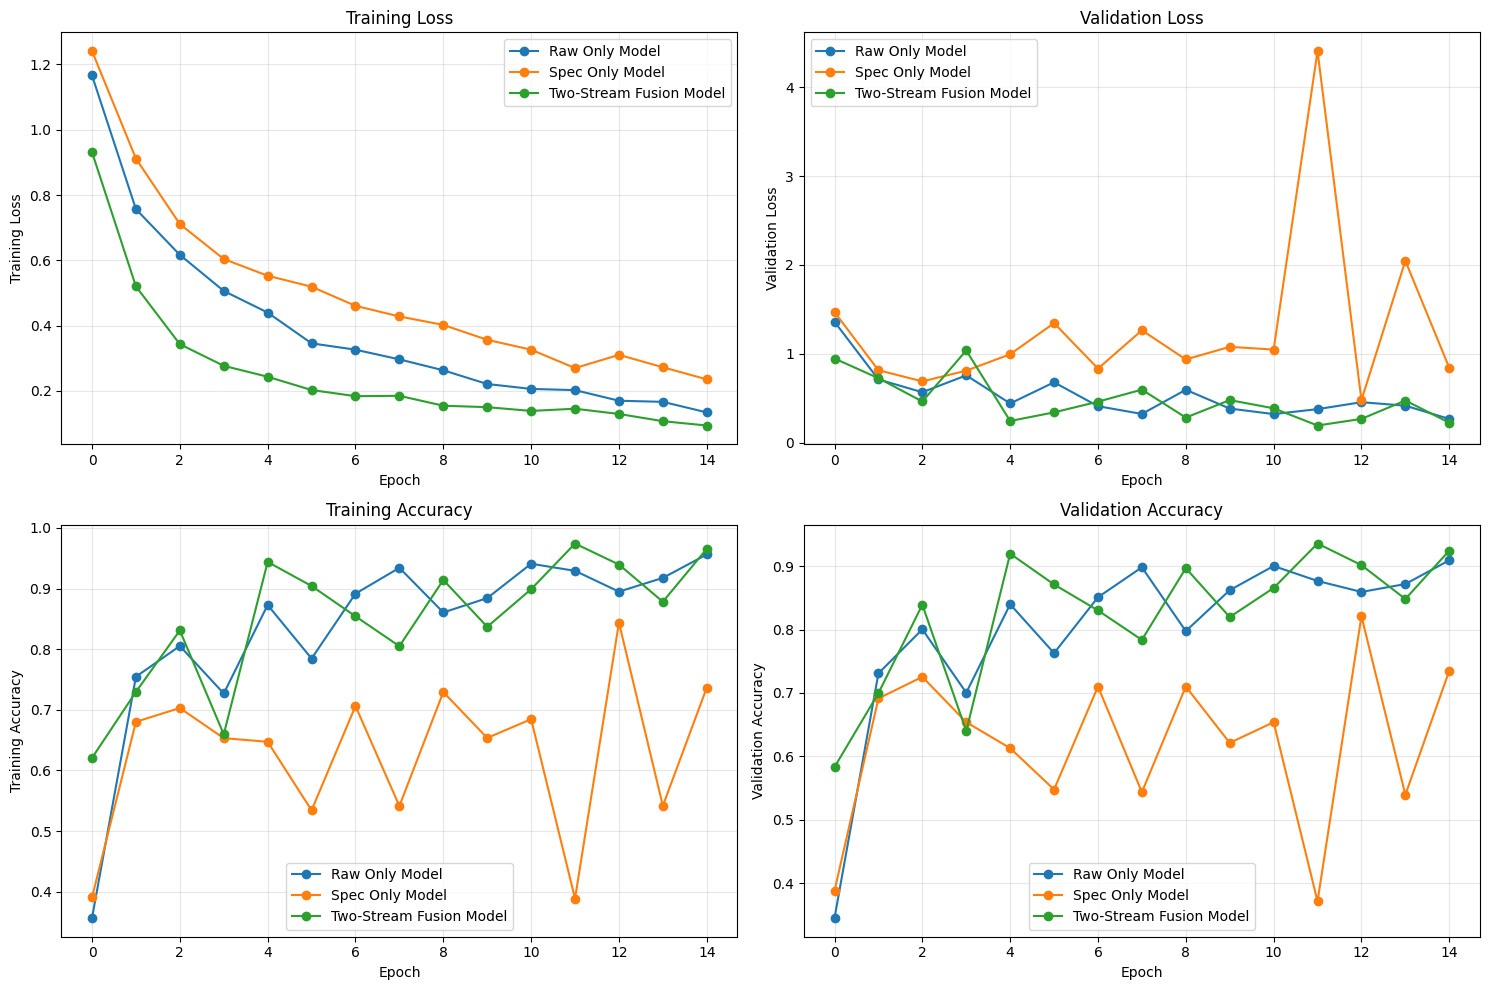


FINAL EVALUATION ON TEST SET

Evaluating Raw Only Model
Test Loss: 0.3492
Test Accuracy: 0.8883 (88.83%)
Test Macro F1: 0.8887

CLASSIFICATION REPORT - Raw Only Model
              precision    recall  f1-score   support

          up     0.9736    0.8682    0.9179       425
        down     0.8665    0.9113    0.8884       406
        left     0.8041    0.9466    0.8696       412
       right     0.9397    0.8258    0.8790       396

    accuracy                         0.8883      1639
   macro avg     0.8960    0.8880    0.8887      1639
weighted avg     0.8963    0.8883    0.8890      1639



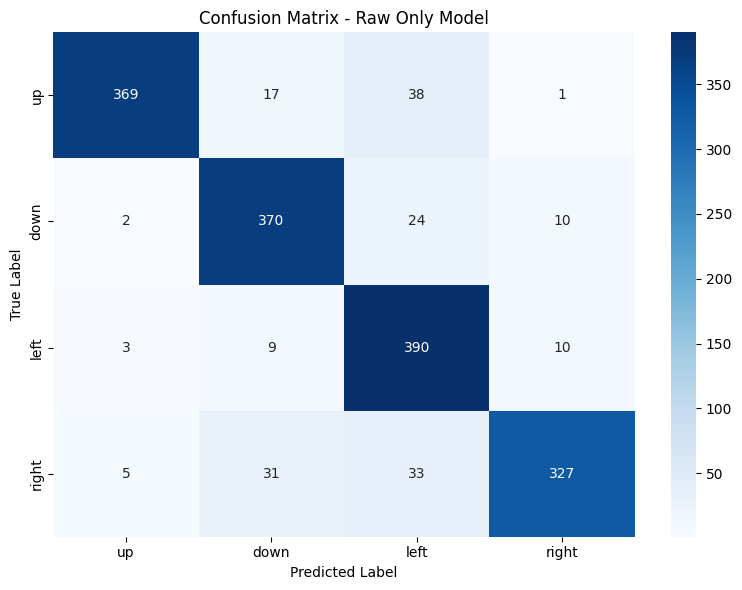


Evaluating Spec Only Model
Test Loss: 0.5960
Test Accuracy: 0.7846 (78.46%)
Test Macro F1: 0.7821

CLASSIFICATION REPORT - Spec Only Model
              precision    recall  f1-score   support

          up     0.9848    0.6094    0.7529       425
        down     0.8162    0.9409    0.8741       406
        left     0.7978    0.6893    0.7396       412
       right     0.6540    0.9116    0.7616       396

    accuracy                         0.7846      1639
   macro avg     0.8132    0.7878    0.7821      1639
weighted avg     0.8161    0.7846    0.7817      1639



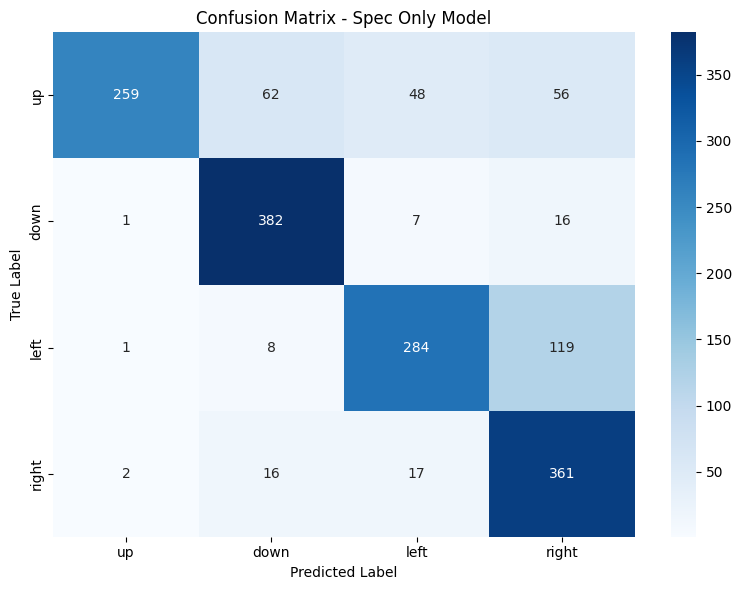


Evaluating Two-Stream Fusion Model
Test Loss: 0.2448
Test Accuracy: 0.9213 (92.13%)
Test Macro F1: 0.9201

CLASSIFICATION REPORT - Two-Stream Fusion Model
              precision    recall  f1-score   support

          up     0.9506    0.9506    0.9506       425
        down     0.8989    0.9631    0.9298       406
        left     0.8902    0.9442    0.9164       412
       right     0.9532    0.8232    0.8835       396

    accuracy                         0.9213      1639
   macro avg     0.9232    0.9203    0.9201      1639
weighted avg     0.9232    0.9213    0.9206      1639



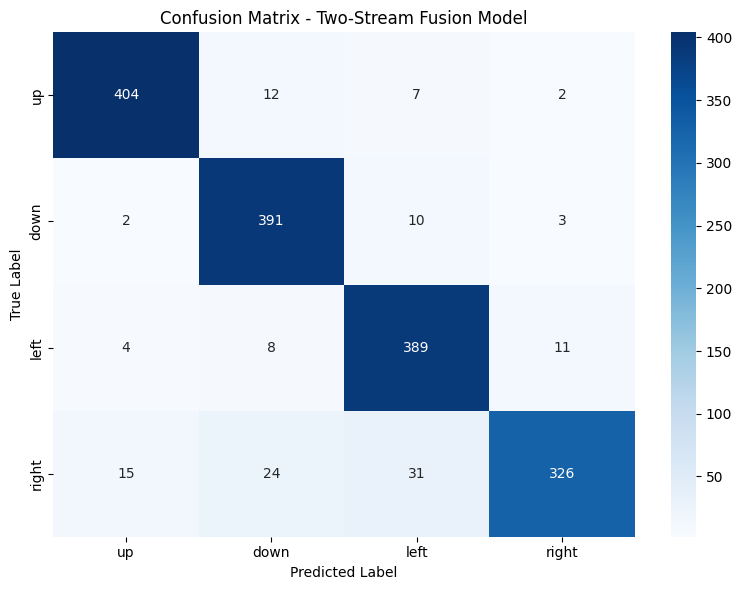

In [ ]:
# Train all three models
models_info = [
    ("Raw Only Model", RawOnlyModel(num_classes=len(TARGET_LABELS), embedding_dim=EMBEDDING_DIM)),
    ("Spec Only Model", SpecOnlyModel(num_classes=len(TARGET_LABELS), embedding_dim=EMBEDDING_DIM)),
    ("Two-Stream Fusion Model", TwoStreamFusionModel(num_classes=len(TARGET_LABELS), embedding_dim=EMBEDDING_DIM))
]

trained_models = []
histories = []
model_names = []

for name, model in models_info:
    trained_model, history = train_model(model, train_loader, val_loader, name, epochs=EPOCHS, lr=LR)
    trained_models.append(trained_model)
    histories.append(history)
    model_names.append(name)

# Plot training comparison
plot_training_history(histories, model_names)

# Evaluate all models
print("\n" + "="*80)
print("FINAL EVALUATION ON TEST SET")
print("="*80)

results = []
for name, model in zip(model_names, trained_models):
    acc, f1, y_true, y_pred = evaluate_and_visualize(model, test_loader, name)
    results.append((name, acc, f1))



In [ ]:
# Summary comparison
print("\n" + "="*80)
print("PERFORMANCE SUMMARY")
print("="*80)
print(f"{'Model':<30} {'Accuracy':<15} {'Macro F1':<15}")
print("-"*80)
for name, acc, f1 in results:
    print(f"{name:<30} {acc:<15.4f} {f1:<15.4f}")


PERFORMANCE SUMMARY
Model                          Accuracy        Macro F1       
--------------------------------------------------------------------------------
Raw Only Model                 0.8883          0.8887         
Spec Only Model                0.7846          0.7821         
Two-Stream Fusion Model        0.9213          0.9201         


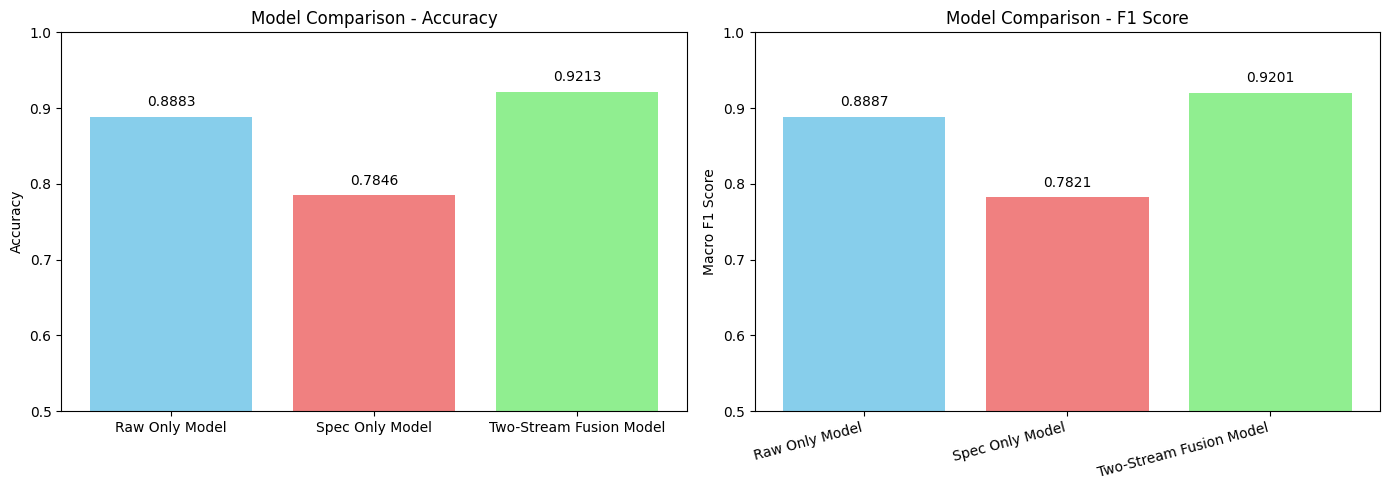

In [ ]:
# Create comparison bar plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names = [r[0] for r in results]
accs = [r[1] for r in results]
f1s = [r[2] for r in results]

ax1.bar(names, accs, color=['skyblue', 'lightcoral', 'lightgreen'])
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Comparison - Accuracy')
ax1.set_ylim([0.5, 1.0])
for i, v in enumerate(accs):
    ax1.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

ax2.bar(names, f1s, color=['skyblue', 'lightcoral', 'lightgreen'])
ax2.set_ylabel('Macro F1 Score')
ax2.set_title('Model Comparison - F1 Score')
ax2.set_ylim([0.5, 1.0])
for i, v in enumerate(f1s):
    ax2.text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()